<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



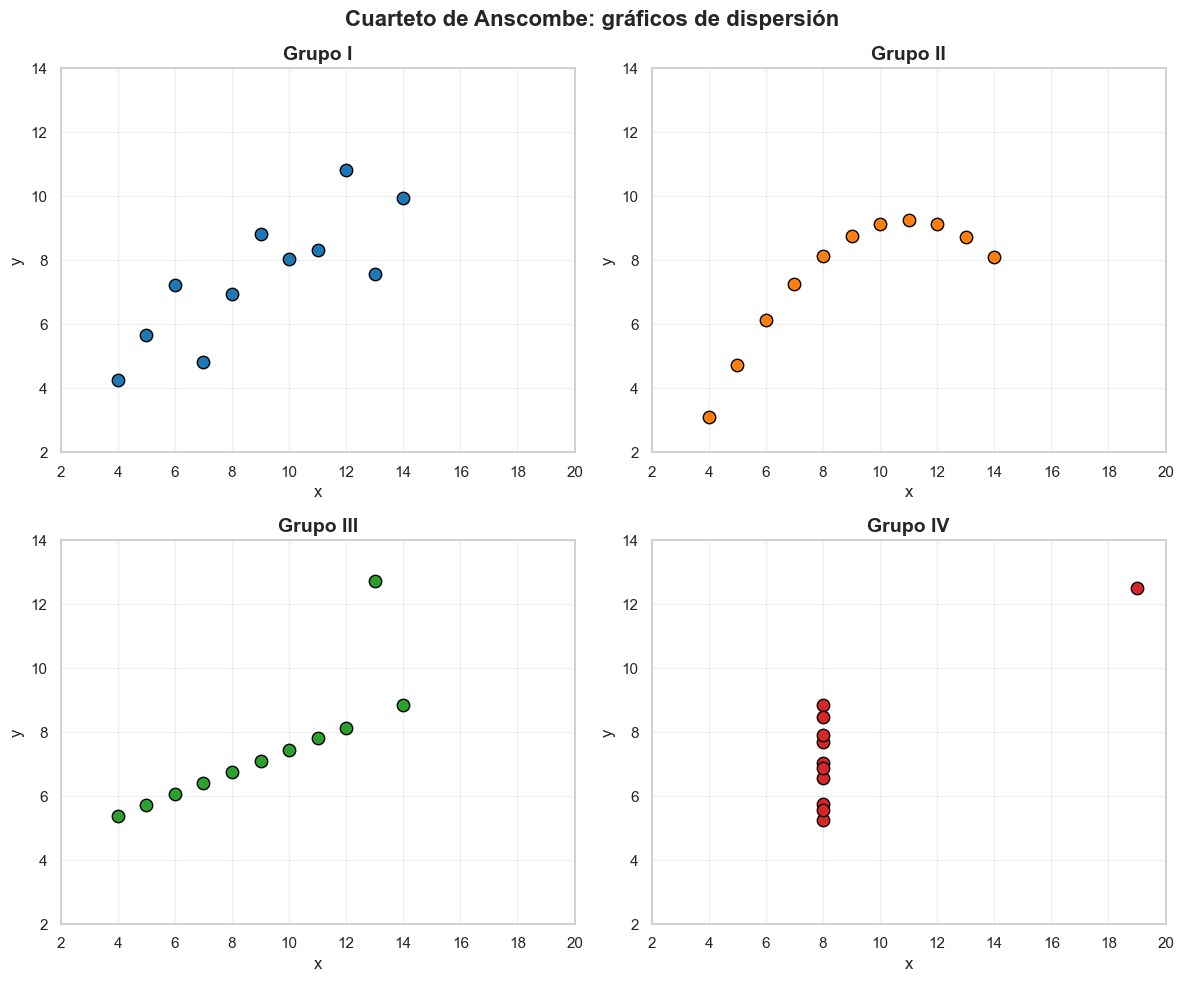


Observaciones:
- Grupo I: relación lineal clara y bien distribuida.
- Grupo II: relación claramente NO lineal (curva cuadrática).
- Grupo III: relación lineal con un outlier evidente que desplaza la recta.
- Grupo IV: x casi constante salvo por un único valor (outlier extremo).


In [2]:
# 1. Gráfico de dispersión para cada grupo del cuarteto de Anscombe

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, group in enumerate(['I', 'II', 'III', 'IV']):
    subset = data[data['dataset'] == group]
    axes[i].scatter(subset['x'], subset['y'], s=80, color=colors[i], edgecolor='black')
    axes[i].set_title(f'Grupo {group}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(2, 20)
    axes[i].set_ylim(2, 14)

plt.suptitle('Cuarteto de Anscombe: gráficos de dispersión', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservaciones:")
print("- Grupo I: relación lineal clara y bien distribuida.")
print("- Grupo II: relación claramente NO lineal (curva cuadrática).")
print("- Grupo III: relación lineal con un outlier evidente que desplaza la recta.")
print("- Grupo IV: x casi constante salvo por un único valor (outlier extremo).")

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [3]:
# 2. Resumen estadístico por grupo

print("=" * 60)
print("RESUMEN ESTADÍSTICO POR GRUPO")
print("=" * 60)
for group in ['I', 'II', 'III', 'IV']:
    subset = data[data['dataset'] == group]
    print(f"\nGrupo {group}:")
    print(subset[['x', 'y']].describe().round(4))
    print(f"Correlación (x, y): {subset['x'].corr(subset['y']):.4f}")

# Tabla resumen comparativa
print("\n" + "=" * 60)
print("TABLA COMPARATIVA DE ESTADÍSTICOS")
print("=" * 60)
resumen = data.groupby('dataset').agg(
    x_mean=('x', 'mean'),
    x_var=('x', 'var'),
    y_mean=('y', 'mean'),
    y_var=('y', 'var'),
).round(4)
resumen['correlacion'] = [data[data['dataset'] == g]['x'].corr(data[data['dataset'] == g]['y']).round(4)
                          for g in ['I', 'II', 'III', 'IV']]
print(resumen)

print("\nInterpretación:")
print("Los cuatro grupos tienen prácticamente los mismos estadísticos descriptivos")
print("(misma media en x e y, misma varianza, misma correlación ≈ 0.816),")
print("pero su comportamiento gráfico es radicalmente distinto.")
print("Esto demuestra que las estadísticas resumen NO bastan para entender los datos.")

RESUMEN ESTADÍSTICO POR GRUPO

Grupo I:
             x        y
count  11.0000  11.0000
mean    9.0000   7.5009
std     3.3166   2.0316
min     4.0000   4.2600
25%     6.5000   6.3150
50%     9.0000   7.5800
75%    11.5000   8.5700
max    14.0000  10.8400
Correlación (x, y): 0.8164

Grupo II:
             x        y
count  11.0000  11.0000
mean    9.0000   7.5009
std     3.3166   2.0317
min     4.0000   3.1000
25%     6.5000   6.6950
50%     9.0000   8.1400
75%    11.5000   8.9500
max    14.0000   9.2600
Correlación (x, y): 0.8162

Grupo III:
             x        y
count  11.0000  11.0000
mean    9.0000   7.5000
std     3.3166   2.0304
min     4.0000   5.3900
25%     6.5000   6.2500
50%     9.0000   7.1100
75%    11.5000   7.9800
max    14.0000  12.7400
Correlación (x, y): 0.8163

Grupo IV:
             x        y
count  11.0000  11.0000
mean    9.0000   7.5009
std     3.3166   2.0306
min     8.0000   5.2500
25%     8.0000   6.1700
50%     8.0000   7.0400
75%     8.0000   8.1900
max  

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



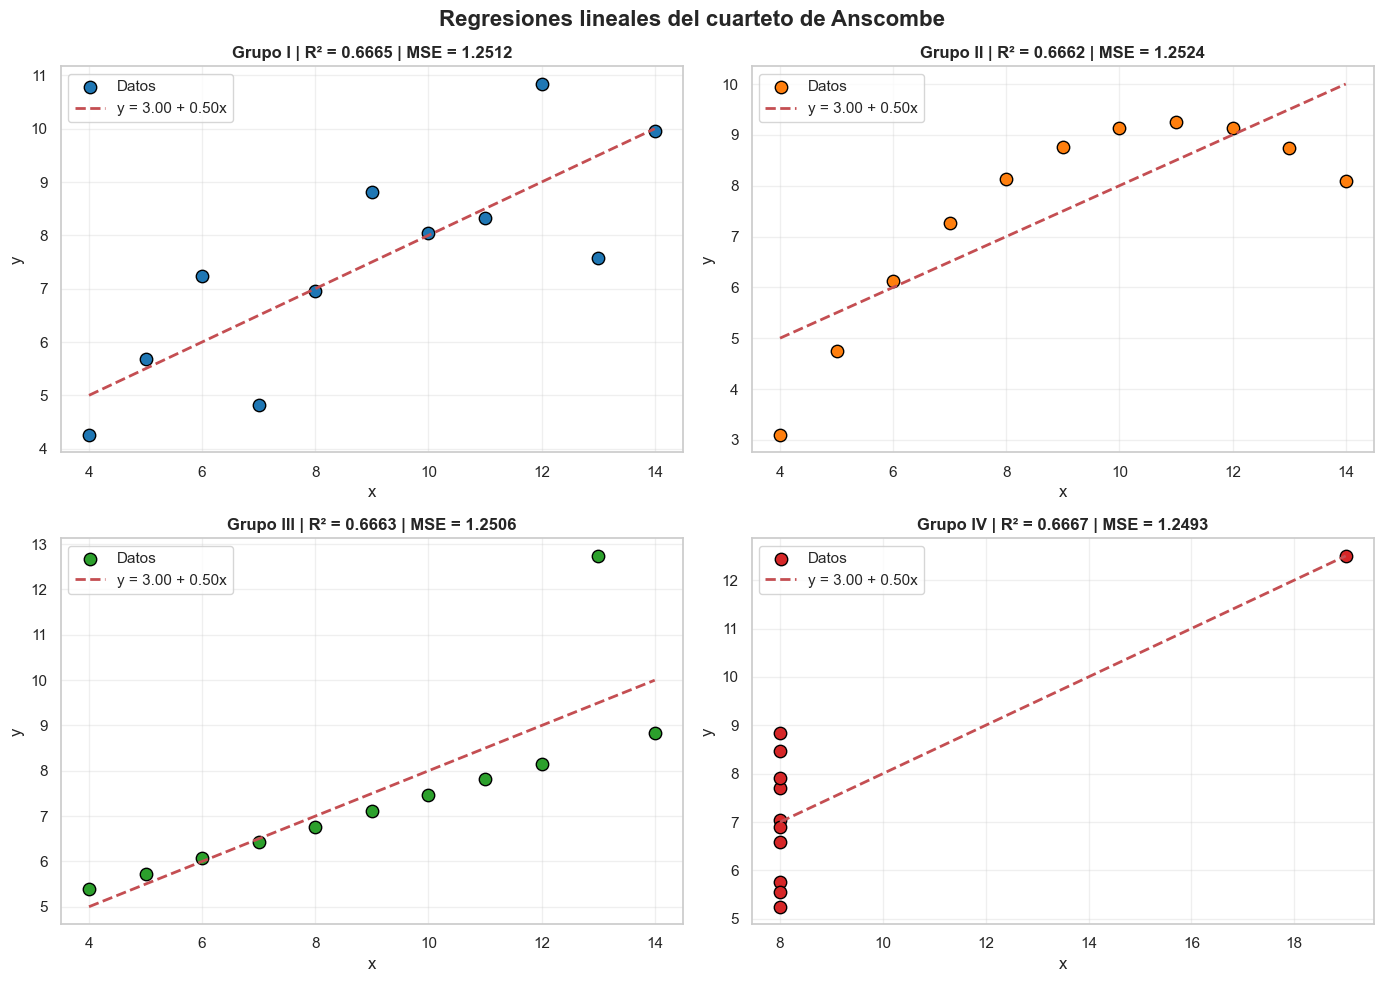


RESULTADOS DE LA REGRESIÓN LINEAL
grupo  beta_0  beta_1    MSE     R²
    I  3.0001  0.5001 1.2512 0.6665
   II  3.0009  0.5000 1.2524 0.6662
  III  3.0025  0.4997 1.2506 0.6663
   IV  3.0017  0.4999 1.2493 0.6667

Interpretación:
Los cuatro grupos producen prácticamente la MISMA recta de regresión
(y ≈ 3.00 + 0.50x) y el mismo R² ≈ 0.667.
Sin embargo, la calidad del ajuste es muy distinta en términos visuales:
- Grupo I: ajuste apropiado.
- Grupo II: la regresión lineal NO captura el patrón curvo real.
- Grupo III: el outlier infla la recta; sin él el ajuste sería casi perfecto.
- Grupo IV: la regresión depende casi únicamente de un punto atípico.


In [4]:
# 3. Regresión lineal para cada grupo

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

resultados_regresion = []

for i, group in enumerate(['I', 'II', 'III', 'IV']):
    subset = data[data['dataset'] == group]
    X = subset[['x']].values
    y = subset['y'].values

    # Ajustar modelo
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    # Métricas
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    beta_0 = model.intercept_
    beta_1 = model.coef_[0]

    resultados_regresion.append({
        'grupo': group,
        'beta_0': round(beta_0, 4),
        'beta_1': round(beta_1, 4),
        'MSE': round(mse, 4),
        'R²': round(r2, 4)
    })

    # Gráfico
    axes[i].scatter(subset['x'], subset['y'], s=80, color=colors[i], edgecolor='black', label='Datos')
    x_line = np.linspace(subset['x'].min(), subset['x'].max(), 100).reshape(-1, 1)
    axes[i].plot(x_line, model.predict(x_line), 'r--', linewidth=2, label=f'y = {beta_0:.2f} + {beta_1:.2f}x')
    axes[i].set_title(f'Grupo {group} | R² = {r2:.4f} | MSE = {mse:.4f}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Regresiones lineales del cuarteto de Anscombe', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("RESULTADOS DE LA REGRESIÓN LINEAL")
print("=" * 60)
df_resultados = pd.DataFrame(resultados_regresion)
print(df_resultados.to_string(index=False))

print("\nInterpretación:")
print("Los cuatro grupos producen prácticamente la MISMA recta de regresión")
print("(y ≈ 3.00 + 0.50x) y el mismo R² ≈ 0.667.")
print("Sin embargo, la calidad del ajuste es muy distinta en términos visuales:")
print("- Grupo I: ajuste apropiado.")
print("- Grupo II: la regresión lineal NO captura el patrón curvo real.")
print("- Grupo III: el outlier infla la recta; sin él el ajuste sería casi perfecto.")
print("- Grupo IV: la regresión depende casi únicamente de un punto atípico.")

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.

ESTRATEGIAS DE MEJORA POR GRUPO

Grupo I → Regresión lineal estándar: R² = 0.6665
Grupo II → Regresión polinomial grado 2: R² = 1.0000 (vs lineal R² ≈ 0.667)
Grupo III → Lineal sin outlier: R² = 1.0000
Grupo IV → Regresión Huber: R² = 0.6666
   Nota: este grupo es problemático por construcción (x casi constante).
   Ninguna regresión 'standard' puede modelarlo correctamente sin más datos.


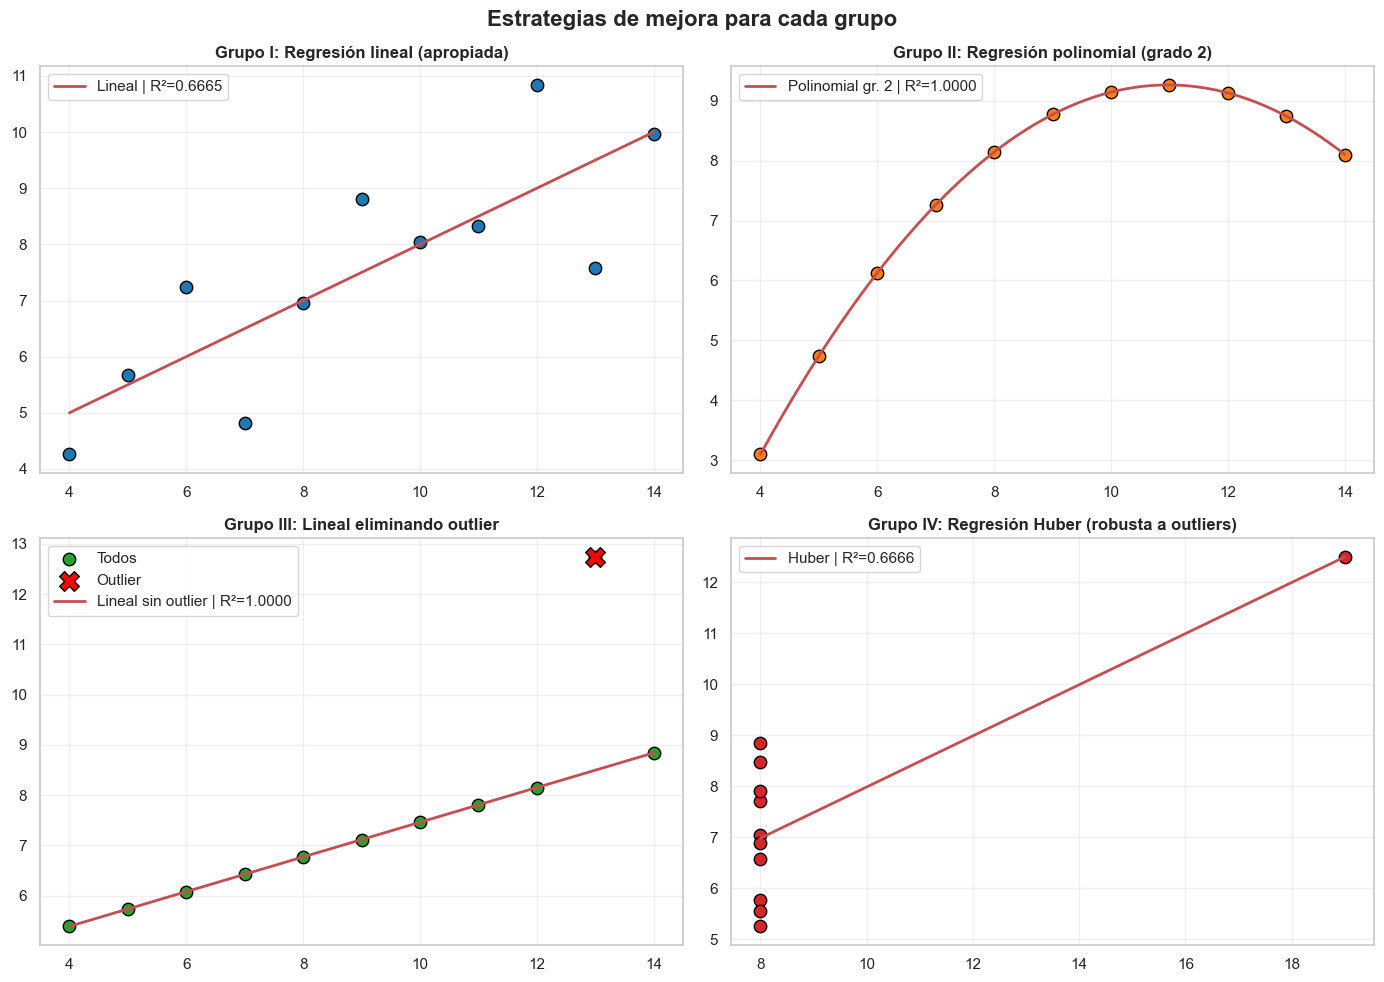


CONCLUSIONES FINALES
1. Siempre VISUALIZAR los datos antes de modelar.
2. La elección del modelo debe basarse en la estructura real de los datos.
3. Detectar y manejar outliers es esencial para regresión lineal.
4. Métodos robustos (Huber, RANSAC) ayudan cuando hay puntos atípicos.
5. Modelos no lineales (polinomial, splines) capturan patrones curvos.


In [5]:
# 4. Estrategias de mejora para cada grupo

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import HuberRegressor

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("=" * 60)
print("ESTRATEGIAS DE MEJORA POR GRUPO")
print("=" * 60)

# Grupo I: regresión lineal estándar (ya está bien)
g = 'I'
subset = data[data['dataset'] == g]
X = subset[['x']].values
y = subset['y'].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
axes[0].scatter(subset['x'], subset['y'], s=80, color=colors[0], edgecolor='black')
x_line = np.linspace(subset['x'].min(), subset['x'].max(), 100).reshape(-1, 1)
axes[0].plot(x_line, model.predict(x_line), 'r-', linewidth=2, label=f'Lineal | R²={r2:.4f}')
axes[0].set_title('Grupo I: Regresión lineal (apropiada)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
print(f"\nGrupo I → Regresión lineal estándar: R² = {r2:.4f}")

# Grupo II: regresión polinomial (grado 2)
g = 'II'
subset = data[data['dataset'] == g]
X = subset[['x']].values
y = subset['y'].values
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model = LinearRegression().fit(X_poly, y)
y_pred = model.predict(X_poly)
r2 = r2_score(y, y_pred)
x_line = np.linspace(subset['x'].min(), subset['x'].max(), 100).reshape(-1, 1)
axes[1].scatter(subset['x'], subset['y'], s=80, color=colors[1], edgecolor='black')
axes[1].plot(x_line, model.predict(poly.transform(x_line)), 'r-', linewidth=2, label=f'Polinomial gr. 2 | R²={r2:.4f}')
axes[1].set_title('Grupo II: Regresión polinomial (grado 2)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
print(f"Grupo II → Regresión polinomial grado 2: R² = {r2:.4f} (vs lineal R² ≈ 0.667)")

# Grupo III: eliminar outlier
g = 'III'
subset = data[data['dataset'] == g].copy()
# Identificar outlier mediante distancia a la mediana
medianas = subset[['x', 'y']].median()
mad = (subset[['x', 'y']] - medianas).abs().sum(axis=1)
outlier_idx = mad.idxmax()
subset_sin_outlier = subset.drop(outlier_idx)

X = subset_sin_outlier[['x']].values
y = subset_sin_outlier['y'].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
axes[2].scatter(subset['x'], subset['y'], s=80, color=colors[2], edgecolor='black', label='Todos')
axes[2].scatter(subset.loc[outlier_idx, 'x'], subset.loc[outlier_idx, 'y'],
                s=200, color='red', marker='X', edgecolor='black', label='Outlier')
x_line = np.linspace(subset['x'].min(), subset['x'].max(), 100).reshape(-1, 1)
axes[2].plot(x_line, model.predict(x_line), 'r-', linewidth=2, label=f'Lineal sin outlier | R²={r2:.4f}')
axes[2].set_title('Grupo III: Lineal eliminando outlier', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
print(f"Grupo III → Lineal sin outlier: R² = {r2:.4f}")

# Grupo IV: el modelo lineal no es apropiado por la estructura misma de los datos.
# Usamos regresión robusta (Huber) que es menos sensible a puntos atípicos.
g = 'IV'
subset = data[data['dataset'] == g]
X = subset[['x']].values
y = subset['y'].values
huber = HuberRegressor().fit(X, y)
y_pred = huber.predict(X)
r2 = r2_score(y, y_pred)
axes[3].scatter(subset['x'], subset['y'], s=80, color=colors[3], edgecolor='black')
x_line = np.linspace(subset['x'].min(), subset['x'].max(), 100).reshape(-1, 1)
axes[3].plot(x_line, huber.predict(x_line), 'r-', linewidth=2, label=f'Huber | R²={r2:.4f}')
axes[3].set_title('Grupo IV: Regresión Huber (robusta a outliers)', fontweight='bold')
axes[3].legend()
axes[3].grid(True, alpha=0.3)
print(f"Grupo IV → Regresión Huber: R² = {r2:.4f}")
print(f"   Nota: este grupo es problemático por construcción (x casi constante).")
print(f"   Ninguna regresión 'standard' puede modelarlo correctamente sin más datos.")

plt.suptitle('Estrategias de mejora para cada grupo', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("CONCLUSIONES FINALES")
print("=" * 60)
print("1. Siempre VISUALIZAR los datos antes de modelar.")
print("2. La elección del modelo debe basarse en la estructura real de los datos.")
print("3. Detectar y manejar outliers es esencial para regresión lineal.")
print("4. Métodos robustos (Huber, RANSAC) ayudan cuando hay puntos atípicos.")
print("5. Modelos no lineales (polinomial, splines) capturan patrones curvos.")